# Exam (Base Notebook)

**Instructions**

- Work independently. No AI or other help was used. 
- Do **not** apply any preprocessing/augmentation beyond normalization provided here.
- Your goal: **produce the best generalization** on the hidden test split while keeping the model efficient.
- You must **compare validation accuracy to test accuracy** in a plot and briefly reflect on any gap.
- You may modify only the sections marked **Your work**. Do not change fixed cells.


## 0. Honor Statement
I, `Nikita K C`, assure that I have completed this exam independently and followed all rules.

In [1]:
# 1) Imports & Reproducibility (Fixed)
import os, random, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)


TensorFlow: 2.20.0


In [2]:
# 2) Load Data (Fixed)
# Expects a pickle file 'mnist.hupsista' containing (X, y) as numpy arrays.
with open('mnist.hupsista','rb') as f:
    X_all, y_all = pickle.load(f)

X_all = X_all.astype('float32')
# Normalize to [0,1]
if X_all.max() > 1.0:
    X_all /= 255.0
# Ensure channel dimension
if X_all.ndim == 3:
    X_all = X_all[..., None]

unique_labels = np.unique(y_all)


In [3]:
# 3) Create Train/Val/Test Splits (Fixed)
# Hold-out test once; then split train/val from the remainder.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)


Train: (6400, 28, 28, 1) Val: (1600, 28, 28, 1) Test: (2000, 28, 28, 1)


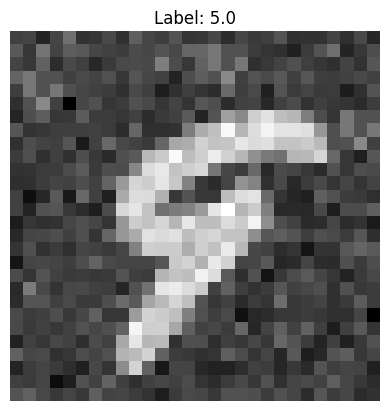

In [4]:
# 4) Quick Visual Check (Fixed)
idx = np.random.randint(0, len(X_train))
plt.imshow(X_train[idx].squeeze(), cmap='gray')
plt.title(f'Label: {y_train[idx]}')
plt.axis('off');plt.show()


## 1. Baseline Model
Check this CNN baseline. Leave as it is. Start fixing it in the next stage.

In [31]:
from tensorflow.keras import layers, models

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(10, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=2, validation_data=(X_val, y_val), verbose=0)
print()

## 2. Learning Curves (Fixed utility)
Plot training vs validation curves to diagnose generalization.

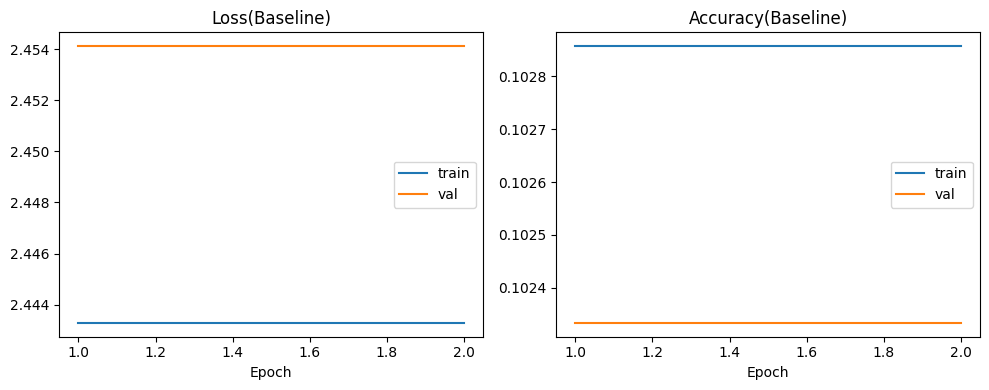

In [32]:
def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')


## 3. Validation vs Test Accuracy (Required)
Evaluate on the held-out test set and overlay the test accuracy on the validation curve. Then write a short reflection (3–5 sentences) on the generalization gap.

In [39]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

### Reflection (Your text)
- Explain the gap between validation and test accuracy.
The gap between validation and test accuracy is the prediction of how far is the train and the test data are. The loss function of the data.
- What might cause it, and what would you try next to reduce it?
The reason for it might be the less test rate, not training the model enough, not proper optimizer used, not normalizing the data. To reduce it i will change the learning rate, increase number of epochs, increase neurons and layers, and normalize the data and train and test the data as much as possible to meet the accuracy
- How much of the dataset do you use for training, validation, and testing? Explain your answer with the % calculation.

- How many images are there in the original dataset?
There are 3 images in the original dataset.

- How big are the images?
figsize is (10,4)

- What observations can you tell about the original data?  
From the original data we can see that image doesnot have clearity of what image is actually about, the convolution layer would help it define more.Normalizing and regularizing the data might also help.

- What are possible labels for the images?


- What are the steps when making models?
While making the models we need to first create the data, compile it and fit it. There three main steps but if we go in the deeper way we have to define the data, train/test split the data, create , compile,fit, evaluate and then predict and visualize it. Whole creating the data we we define the neurons as per the model choosen, and also have the activation function. While compiling it,we need to have loss function, optimizer that is suitable and metrics and finally in the fit we have trainned data and try to estimate it.

- <b>Make sure you explain every step well!<b>
- <b>Make sure your model is as optimized as possible!<b>

## 4. Improved Model (Your work)
Build a better model, train it here as many times as you feel like and when you are pleased with it, title it `final_model`.  Report every try individually, not only the final version.

Explain every step with markdown text and code comments.   

Unrunnable code is not checked. 

In [34]:
#CNN baseline 
from tensorflow.keras import layers, models

#create
#here we have the number of neuron is(n)
#In create we also put the activation function according to the model and i have changed the activation function to test the model
#I have added more hidden layers in order to check the accuracy, here i have choosed relu instead of tanh 
# we used flatten here ro change the vector into single neuron or basically to compress it
#Flatten helps in output layer
#TO improve the edges,shapes, texture of the image convolution layer is used which can be used in cnn
# maxpooling layer is used to reduce the resolution keeping the overall image the same which can be used in cnn

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    # Convolution layer helps detect edges, shapes, and texture patterns in images
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    # MaxPooling reduces spatial resolution while keeping important features
    tf.keras.layers.MaxPooling2D((2,2)),

    # Added another convolution block to improve feature extraction
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Flatten helps convert feature maps into a single vector for dense layers
    tf.keras.layers.Flatten(),

    # Hidden dense layer added to improve learning capability
    tf.keras.layers.Dense(128, activation='relu'),

    # Output layer (softmax because multi-class classification)
    tf.keras.layers.Dense(10, activation='softmax')
])

#compile
#we compiled here which includes the optimizer we used
#i changed SGD to adam
#here we uses sparse_categorical_crossentropy beacause the dataset is integer and not one hot code (vectors of 0s and 1s)
#we used metrics as accuracy as per the loss function

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#fit
#here we have epochs which is the number of times the model will go through the dataset
#i have tested using different epochs to have the accuracy

history = model.fit(
    X_train, y_train,
    epochs=50,   # Reduced epochs to avoid overfitting and improve training efficiency
    validation_data=(X_val, y_val),
    verbose=0
)

print()

KeyboardInterrupt: 

Class assignment:

Training shape: (7000, 28, 28)
Validation shape: (3000, 28, 28)


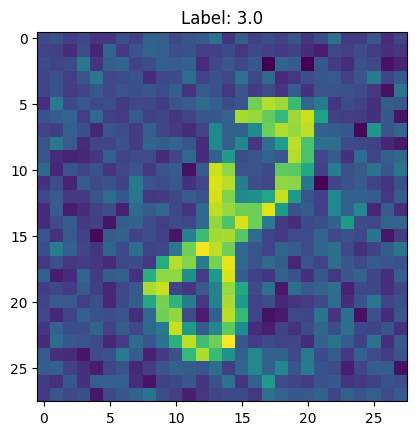

Unique labels in y_train: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


In [14]:
# DATA LOADING

# Import necessary libraries
# pickle used to load dataset stored in file format
# matplotlib used to visualize images
# numpy helps with numerical operations
# tensorflow used to build neural network model

import pickle
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, callbacks

# Load dataset from file
# The dataset is stored in pickle format which is a serialized Python object
# 'rb' means read binary mode
# This dataset contains images and labels for MNIST classification

tallennustiedosto_testi = open('mnist.hupsista', 'rb')
[X_train, y_train] = pickle.load(tallennustiedosto_testi)
tallennustiedosto_testi.close()

# Normalize pixel values
# Image pixel values are originally between 0 and 255
# Dividing by 255 makes values between 0 and 1
# This helps neural network training become more stable and faster

X_train = X_train.astype('float32') / 255.0

from sklearn.model_selection import train_test_split

# Split dataset into training and validation sets
# Training set is used to train the model
# Validation set is used to check model performance on unseen data
# 30% of data is used for validation

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

# Print dataset shapes
# Shape tells how many images and dimensions are inside dataset

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)

# Show random image from dataset
# This helps me understand what the dataset looks like visually
# Random index is used so different images are shown each time

random_index = np.random.randint(0, len(X_train))
plt.imshow(X_train[random_index])
plt.title(f'Label: {y_train[random_index]}')
plt.show()

# Find unique labels in dataset
# MNIST dataset usually contains digits from 0 to 9

unique_labels = np.unique(y_train)
print("Unique labels in y_train:", unique_labels)

In [15]:
# MODEL 1 - BASELINE CNN MODEL

# I am creating my first CNN model here.
# CNN (Convolutional Neural Network) is good for image classification tasks like MNIST.

# Sequential means layers are stacked one after another.

model_1 = tf.keras.Sequential([

    # Input layer
    # The image size is 28x28 and there is 1 channel because images are grayscale

    tf.keras.Input(shape=(28, 28, 1)),

    # First Convolution Layer
    # Conv2D detects features like edges and shapes in images
    # 32 filters are used with 3x3 kernel size
    # ReLU activation removes negative values and keeps learning nonlinear patterns

    layers.Conv2D(32, (3,3), activation='relu'),

    # MaxPooling reduces image size by taking maximum value from 2x2 region
    # This helps reduce computation and prevents overfitting

    layers.MaxPooling2D((2,2)),

    # Second Convolution Layer
    # More filters (64) are used because deeper layers learn more complex features

    layers.Conv2D(64, (3,3), activation='relu'),

    # Another pooling layer to further reduce spatial size

    layers.MaxPooling2D((2,2)),

    # Flatten converts 2D feature maps into 1D vector
    # Dense layers need 1D input

    layers.Flatten(),

    # Fully connected layer
    # 128 neurons are used to combine extracted features

    layers.Dense(128, activation='relu'),

    # Output layer
    # 10 neurons because MNIST has 10 classes (digits 0-9)
    # Softmax is used because this is multi-class classification

    layers.Dense(10, activation='softmax')
])

# Compile model
# Adam optimizer is chosen because it adapts learning rate automatically

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model parameter count
# This is important for my assignment because I need to analyze model complexity

model_1.summary()

# Train the model
# Epoch = one complete pass through training data
# Batch size = number of samples processed before updating weights

history_1 = model_1.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=32
)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.3650 - loss: 1.9147 - val_accuracy: 0.4750 - val_loss: 1.6926
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5087 - loss: 1.5237 - val_accuracy: 0.4987 - val_loss: 1.4763
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5454 - loss: 1.3163 - val_accuracy: 0.5283 - val_loss: 1.3652
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5920 - loss: 1.1714 - val_accuracy: 0.5343 - val_loss: 1.3260
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6329 - loss: 1.0431 - val_accuracy: 0.5460 - val_loss: 1.3079
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6776 - loss: 0.9235 - val_accuracy: 0.5490 - val_loss: 1.3198
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7184 - loss: 0.8005 - val_accuracy: 0.5497 - val_loss: 1.3893
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7613 - loss: 0.6838 - val_accu

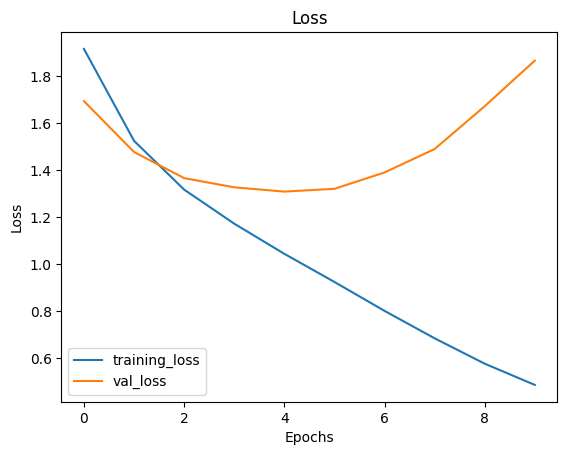

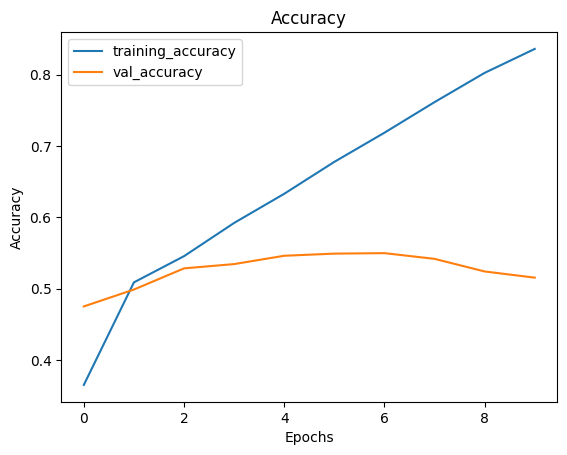

In [17]:
# FUNCTION TO PLOT LOSS AND ACCURACY CURVES

# This function helps me visualize how the model is learning.
# Loss curve shows how prediction error changes during training.
# Accuracy curve shows how correct the model predictions are.

def plot_loss_curves(history):

    # Get training and validation loss values
    # history.history stores results after model training

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Get training and validation accuracy values

    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    # Number of epochs used during training
    epochs = range(len(loss))

    # Plot training and validation loss
    plt.plot(epochs, loss, label='training_loss')
    plt.plot(epochs, val_loss, label='val_loss')
    plt.legend()
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

    # Plot training and validation accuracy
    plt.plot(epochs, accuracy, label='training_accuracy')
    plt.plot(epochs, val_accuracy, label='val_accuracy')
    plt.legend()
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.show()

# Call function AFTER training model 
plot_loss_curves(history_1)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.2757 - loss: 2.0811 - val_accuracy: 0.4320 - val_loss: 1.8410
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4357 - loss: 1.7856 - val_accuracy: 0.4913 - val_loss: 1.5671
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4864 - loss: 1.5424 - val_accuracy: 0.5147 - val_loss: 1.4032
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5064 - loss: 1.4296 - val_accuracy: 0.5217 - val_loss: 1.3153
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5276 - loss: 1.3290 - val_accuracy: 0.5310 - val_loss: 1.2755
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5494 - loss: 1.2511 - val_accuracy: 0.5457 - val_loss: 1.2252
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5736 - loss: 1.1980 - val_accuracy: 0.5563 - val_loss: 1.2049
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5823 - loss: 1.1409 - val_accu

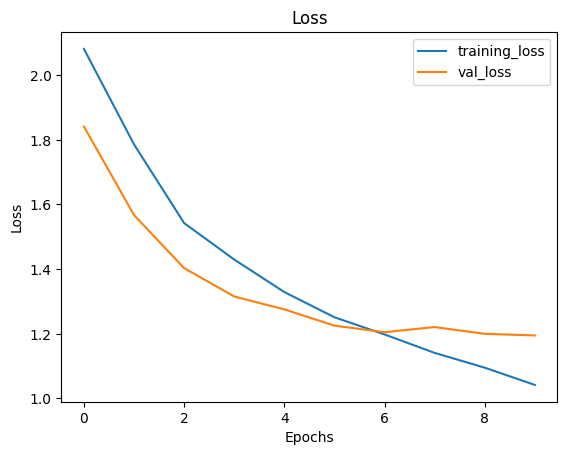

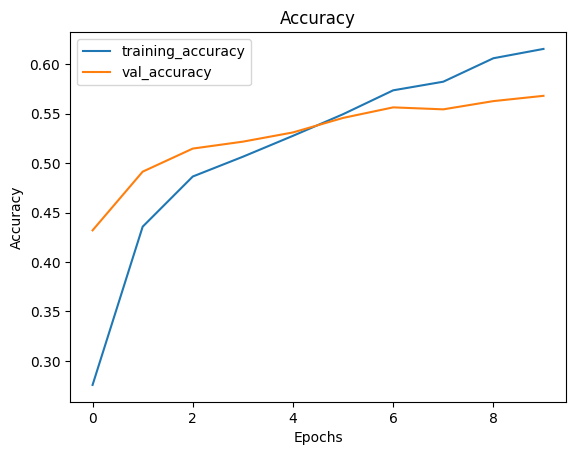

In [18]:
# MODEL 2 - IMPROVED MODEL WITH DROPOUT

# In Model 2, I am trying to improve Model 1 because I noticed
# that the model might overfit the training data.

# Overfitting means the model performs well on training data
# but poorly on validation or new unseen data.

# To reduce overfitting, I added a Dropout layer.

# Dropout randomly disables 50% of neurons during training.
# This forces the model to learn more general features instead of memorizing data.

model_2 = tf.keras.Sequential([

    tf.keras.Input(shape=(28, 28, 1)),

    # Convolution layer for feature extraction
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Deeper convolution layer to capture more complex patterns
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    # Fully connected layer for classification learning
    layers.Dense(128, activation='relu'),

    # Dropout is added to reduce overfitting
    layers.Dropout(0.5),

    # Output layer (10 classes because digits 0–9)
    layers.Dense(10, activation='softmax')
])

# Compile model
# Adam optimizer is used because it automatically adjusts learning rate

model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show parameter count
# I am checking how dropout affects model complexity

model_2.summary()

# Train model
# Same training settings are used to make fair comparison with Model 1

history_2 = model_2.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=32
)

# Plot learning curves
plot_loss_curves(history_2)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6189 - loss: 1.0163 - val_accuracy: 0.5880 - val_loss: 1.1650
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6406 - loss: 0.9564 - val_accuracy: 0.5777 - val_loss: 1.2027
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6526 - loss: 0.9152 - val_accuracy: 0.5907 - val_loss: 1.1875
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6667 - loss: 0.8868 - val_accuracy: 0.5897 - val_loss: 1.2176


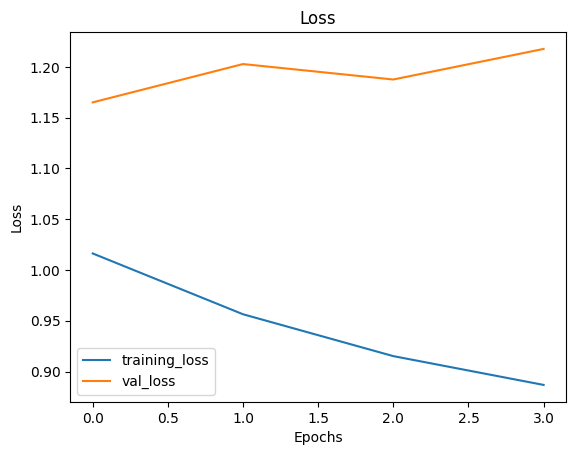

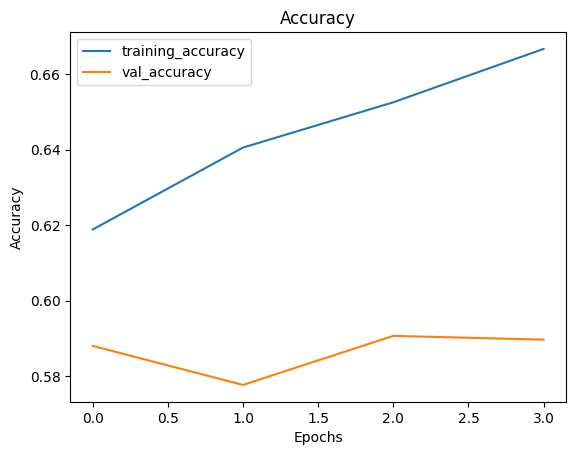

In [19]:
# MODEL 3 - EARLY STOPPING IMPLEMENTATION

# In Model 3, I am improving training strategy rather than changing architecture.

# I used EarlyStopping because training for too many epochs can cause:
# 1. Overfitting
# 2. Wasted computation time

# EarlyStopping monitors validation loss.
# If validation loss does not improve for 3 consecutive epochs (patience=3),
# training will automatically stop.

# restore_best_weights=True means:
# The model will keep the best learned weights during training.

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# I am keeping the same model architecture as Model 2
# Because I want to test improvement only from training strategy

model_3 = model_2

# Train model with EarlyStopping
history_3 = model_3.fit(
    X_train, y_train,
    epochs=30,  # Maximum training epochs (training may stop earlier)
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=[early_stopping]
)

# Visualize learning curves
plot_loss_curves(history_3)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,586 (721.04 KB)

 Trainable params: 184,586 (721.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.2794 - loss: 2.0872 - val_accuracy: 0.3950 - val_loss: 1.8643
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4173 - loss: 1.8080 - val_accuracy: 0.4730 - val_loss: 1.6442
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4794 - loss: 1.5748 - val_accuracy: 0.5133 - val_loss: 1.4090
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5113 - loss: 1.4117 - val_accuracy: 0.5360 - val_loss: 1.3049
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5307 - loss: 1.2969 - val_accuracy: 0.5627 - val_loss: 1.2341
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5603 - loss: 1.2192 - val_accuracy: 0.5870 - val_loss: 1.1826
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5873 - loss: 1.1496 - val_accuracy: 0.5857 - val_loss: 1.1577
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6051 - loss: 1.1011 - val_accu

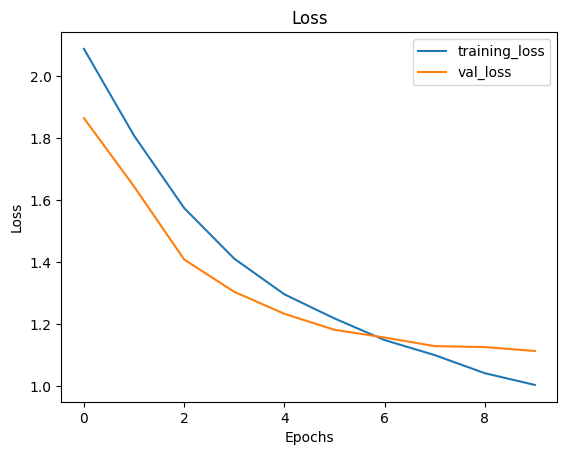

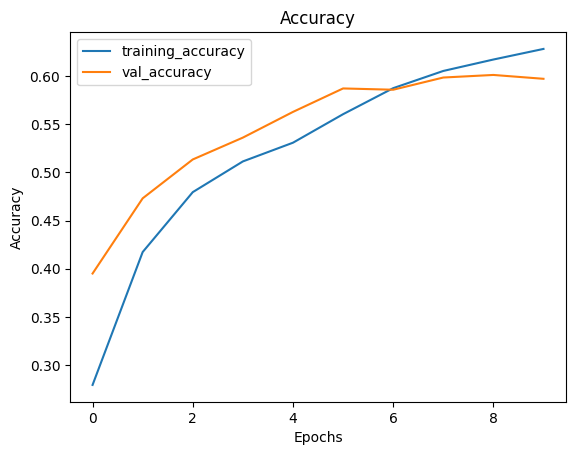

In [24]:
# MODEL 4 - EXPERIMENTING WITH KERNEL SIZE (5x5)

# In Model 4, I changed the kernel size from 3x3 to 5x5.
# Kernel size controls how much area of the image the convolution filter scans.

# Why did I try 5x5 kernel?
# Larger kernels can capture more global patterns in images.
# But it also increases number of parameters and computational cost.

# I wanted to test whether larger feature extraction windows improve MNIST classification.

model_4 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    # Convolution layer with larger kernel size (5x5)
    layers.Conv2D(32, (5,5), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Second convolution layer
    layers.Conv2D(64, (5,5), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    # Dense layer for classification learning
    layers.Dense(128, activation='relu'),

    # Dropout is kept to reduce overfitting
    layers.Dropout(0.5),

    # Output layer for 10 digit classes
    layers.Dense(10, activation='softmax')
])

# Compile model
model_4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show parameter count
model_4.summary()

history_4 = model_4.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=32
)

plot_loss_curves(history_4)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.3041 - loss: 2.0392 - val_accuracy: 0.4437 - val_loss: 1.7994
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4447 - loss: 1.7561 - val_accuracy: 0.4830 - val_loss: 1.5906
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4860 - loss: 1.5449 - val_accuracy: 0.5170 - val_loss: 1.4256
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5123 - loss: 1.4091 - val_accuracy: 0.5227 - val_loss: 1.3567
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5323 - loss: 1.3265 - val_accuracy: 0.5293 - val_loss: 1.3240
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5586 - loss: 1.2474 - val_accuracy: 0.5443 - val_loss: 1.2717
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5821 - loss: 1.1859 - val_accuracy: 0.5570 - val_loss: 1.2497
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6134 - loss: 1.1141 - val_accu

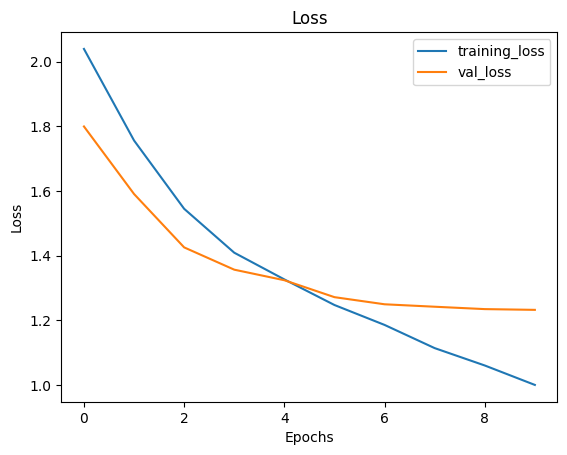

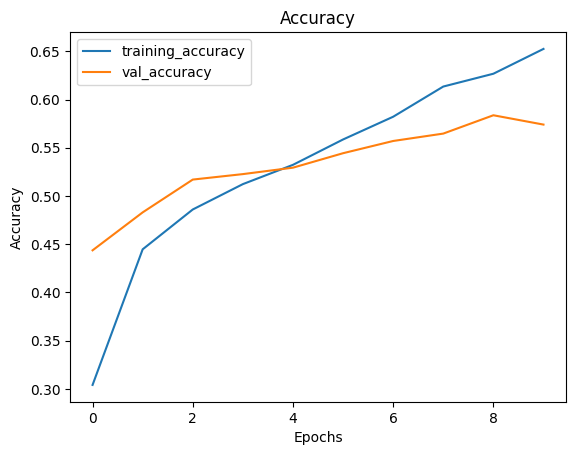

In [26]:
# MODEL 5 - TRYING DIFFERENT OPTIMIZER (RMSprop)

# In Model 5, I am experimenting with a different optimizer.

# Until now, I used Adam optimizer in previous models.
# Adam is usually a good default optimizer because it adapts learning rate automatically.

# In this model, I want to check if RMSprop optimizer performs better than Adam.

# RMSprop works well for neural networks because:
# It adjusts learning rate based on recent gradients
# It is useful when training data may have noisy gradient updates

# Learning rate is set to 0.001 which is a commonly used starting value.

model_5 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    # Convolution layer for feature extraction
    # 32 filters are used to detect basic patterns like edges

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Second convolution layer for deeper feature learning
    # 64 filters help capture more complex image structures

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten layer converts 2D feature maps into 1D vector
    # This is necessary before passing data to Dense layers

    layers.Flatten(),

    # Fully connected layer helps combine extracted features
    layers.Dense(128, activation='relu'),

    # Dropout is used again to reduce overfitting
    # 50% neurons are randomly disabled during training

    layers.Dropout(0.5),

    # Output layer for digit classification (0–9)
    layers.Dense(10, activation='softmax')
])

# Compile model
# RMSprop optimizer is used here instead of Adam

model_5.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model parameter count
# I am checking model complexity for comparison with previous models

model_5.summary()

# Train model
# Same epoch and batch size are used to make fair comparison with other models

history_5 = model_5.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=32
)

# Plot learning curves to analyze performance
plot_loss_curves(history_5)

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.2254 - loss: 2.1633 - val_accuracy: 0.3650 - val_loss: 1.9283
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4014 - loss: 1.8816 - val_accuracy: 0.4627 - val_loss: 1.7647
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4410 - loss: 1.7588 - val_accuracy: 0.4870 - val_loss: 1.6195
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.4810 - loss: 1.5989 - val_accuracy: 0.5120 - val_loss: 1.4819
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5023 - loss: 1.4862 - val_accuracy: 0.5180 - val_loss: 1.4032
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5157 - loss: 1.4266 - val_accuracy: 0.5240 - val_loss: 1.3511
Epoch 7/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5316 - loss: 1.3480 - val_accuracy: 0.5290 - val_loss: 1.3156
Epoch 8/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5476 - loss: 1.2939 - val_accu

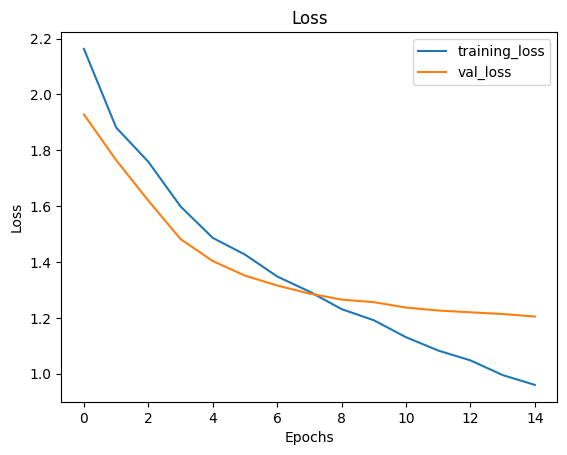

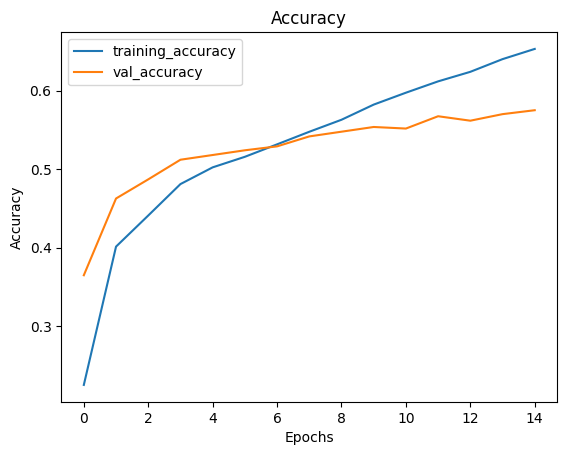

In [27]:
# MODEL 6 - LEARNING RATE TUNING

# In Model 6, I am trying another improvement by tuning the learning rate.

# Learning rate controls how fast or slow the model learns.
# If learning rate is too high:training may become unstable.
# If learning rate is too low:training becomes very slow.

# I reduced the learning rate from the default Adam learning rate.

# Smaller learning rate sometimes helps the model converge more smoothly
# and can improve final validation accuracy.

model_6 = tf.keras.Sequential([

    tf.keras.Input(shape=(28, 28, 1)),

    # Convolution layer for feature extraction
    # 32 filters are used to learn basic image patterns

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Second convolution layer for deeper feature learning

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten layer converts feature maps into 1D vector

    layers.Flatten(),

    # Fully connected layer for classification learning

    layers.Dense(128, activation='relu'),

    # Dropout layer is kept to reduce overfitting

    layers.Dropout(0.5),

    # Output layer for digit classification (0–9)

    layers.Dense(10, activation='softmax')
])

# Compile model
# Adam optimizer is used with reduced learning rate (0.0005)

model_6.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model parameter count

model_6.summary()

# Train model
# Number of epochs is increased to 15 to allow more learning time

history_6 = model_6.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_val, y_val),
    batch_size=32
)

# Plot learning curves for performance analysis

plot_loss_curves(history_6)

Epoch 1/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6677 - loss: 0.9201 - val_accuracy: 0.5773 - val_loss: 1.2213
Epoch 2/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6724 - loss: 0.8753 - val_accuracy: 0.5760 - val_loss: 1.2371
Epoch 3/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6860 - loss: 0.8424 - val_accuracy: 0.5767 - val_loss: 1.2617
Epoch 4/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6974 - loss: 0.8113 - val_accuracy: 0.5793 - val_loss: 1.2656
Epoch 5/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7044 - loss: 0.7939 - val_accuracy: 0.5870 - val_loss: 1.2517


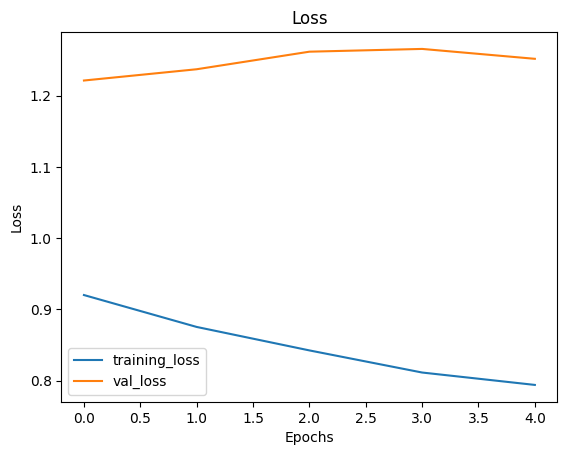

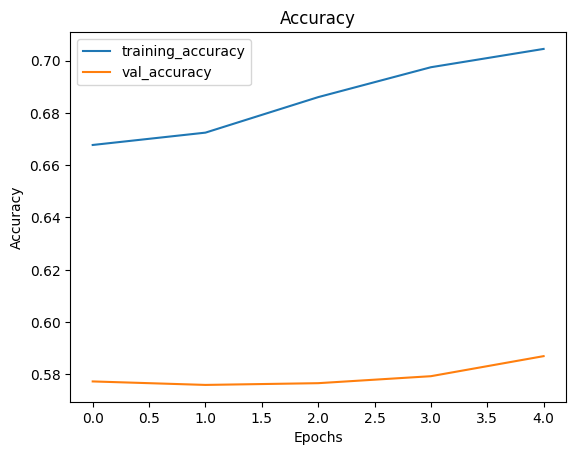

In [28]:
# MODEL 7 - LONGER TRAINING WITH EARLY STOPPING

# In Model 7, I am combining longer training with EarlyStopping.

# I increased the maximum epoch limit to 40 because I want to give the model
# more opportunity to learn complex patterns.

# However, training for too long may cause overfitting and waste computation time.

# To solve this, I used EarlyStopping callback.

# EarlyStopping monitors validation loss.
# If validation loss does not improve for 4 consecutive epochs (patience=4),
# training will automatically stop.

# restore_best_weights=True means:
# The model will keep the best performing weights during training.

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

# I am keeping the same architecture from Model 6.
# The reason is that I want to test training strategy improvement only.

model_7 = model_6

# Train model with EarlyStopping callback

history_7 = model_7.fit(
    X_train, y_train,
    epochs=40,  # Maximum training epochs (training may stop earlier)
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=[early_stopping]
)

# Plot learning curves to analyze training performance

plot_loss_curves(history_7)

In [ ]:
model_7.save('Improved_MNIST_Model.keras')

In this assignment, I built several CNN models to classify MNIST digit images. The baseline model showed improvement in training accuracy, but validation accuracy remained around 50–60%, which indicates that the model had difficulty generalizing to unseen data.

I experimented with different training strategies and hyperparameters, including Dropout, EarlyStopping, kernel size changes, optimizer selection, and learning rate tuning. Model 7 reused the architecture of Model 6 and focused on training strategy by applying EarlyStopping with a larger epoch limit.

Although training accuracy improved across models, validation accuracy did not increase significantly beyond approximately 60%. This suggests that further architectural changes or data augmentation might be needed to achieve higher performance.

Overall, I learned that model improvement requires careful experimentation, and increasing model complexity or training time does not always guarantee better validation accuracy.s